In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns

pd.set_option('display.max_columns', None)

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay


import warnings
warnings.filterwarnings('ignore')

In [83]:
df = pd.read_csv('C:\\Users\\judec\\Downloads\\\\marketing_campaign.csv', sep=';')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [84]:
df.info()
print("\nShape of DataFrame:", df.shape)
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2240,2240,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
unique,NaN,NaN,5,8,NaN,NaN,NaN,663,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Graduation,Married,NaN,NaN,NaN,2012-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1127,864,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5592.159821,1968.805804,NaN,NaN,52247.251354,0.444196,0.506250,NaN,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,NaN,NaN,25173.076661,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,NaN,NaN,1730.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,NaN,NaN,35303.000000,0.000000,0.000000,NaN,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,NaN,NaN,51381.500000,0.000000,0.000000,NaN,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,NaN,NaN,68522.000000,1.000000,1.000000,NaN,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000


In [85]:
df[['Year_Birth', 'Income', 'Dt_Customer', 'Recency', 'NumWebPurchases', 'NumWebVisitsMonth']].describe()

,Year_Birth,Income,Recency,NumWebPurchases,NumWebVisitsMonth
count,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,52247.251354,49.109375,4.084821,5.316518
std,11.984069,25173.076661,28.962453,2.778714,2.426645
min,1893.000000,1730.000000,0.000000,0.000000,0.000000
25%,1959.000000,35303.000000,24.000000,2.000000,3.000000
50%,1970.000000,51381.500000,49.000000,4.000000,6.000000
75%,1977.000000,68522.000000,74.000000,6.000000,7.000000
max,1996.000000,666666.000000,99.000000,27.000000,20.000000


In [ ]:
missing_counts = df.isnull().sum()
print("Missing values per column:\n", missing_counts)


Missing values per column:
 ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


In [ ]:
df['Income'].fillna(df['Income'].median(), inplace=True)
df['Income'].isnull().sum()

np.int64(0)

In [88]:
df.duplicated().sum()

np.int64(0)

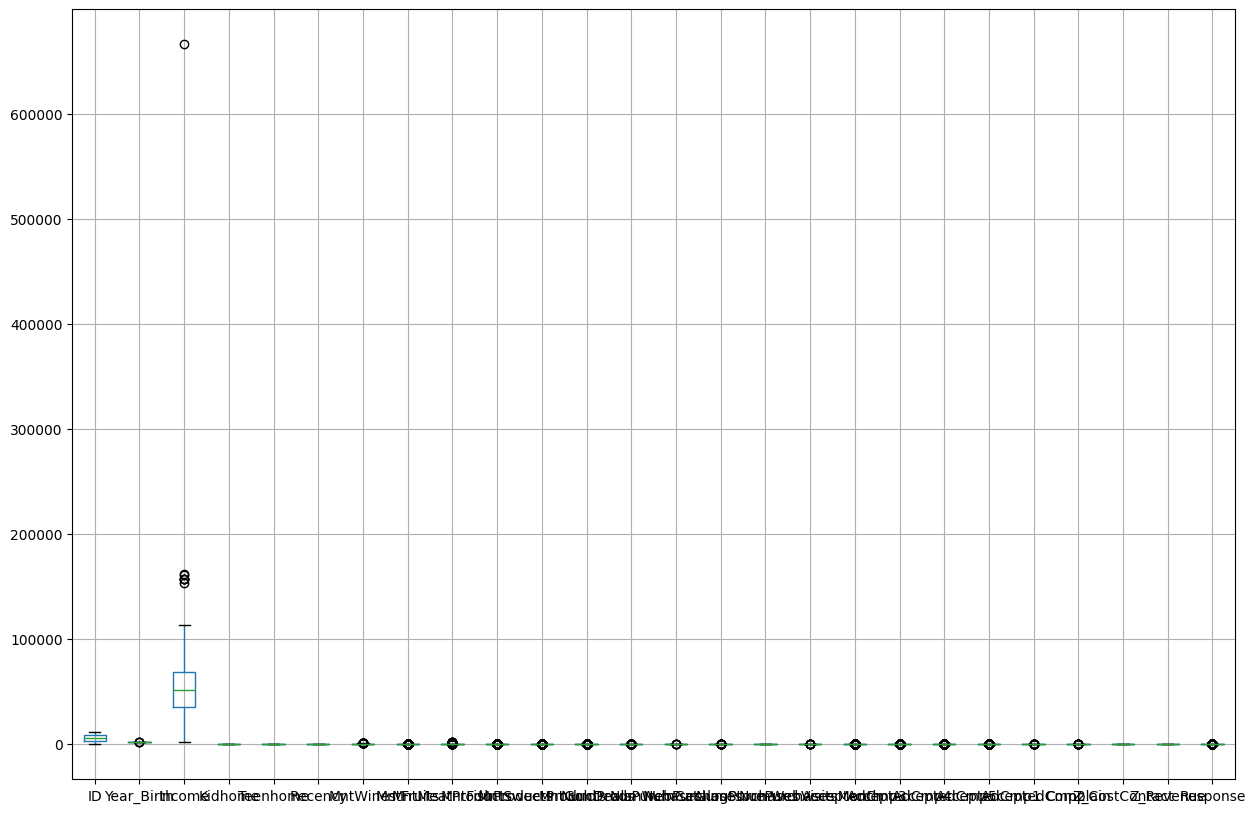

In [89]:
fig, ax = plt.subplots(figsize=(15, 10))
df.boxplot(ax=ax)
plt.show()

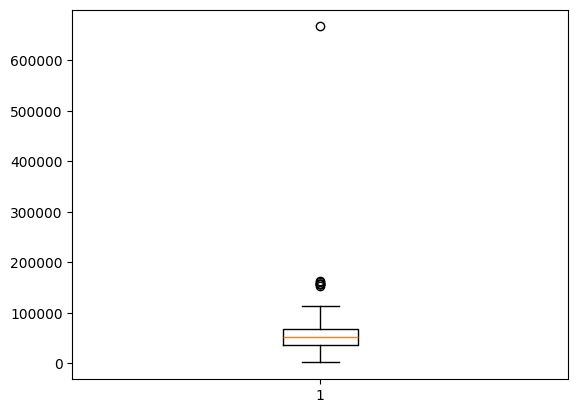

In [ ]:
plt.boxplot(df['Income'])
plt.show()

In [ ]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[~((df['Income'] >= lower_bound) & (df['Income'] <= upper_bound))]
outliers.shape

(8, 29)

In [ ]:
df = df[(df['Income'] >= lower_bound) & (df['Income'] <= upper_bound)]
df.reset_index(drop=True, inplace=True)
df.shape

(2232, 29)

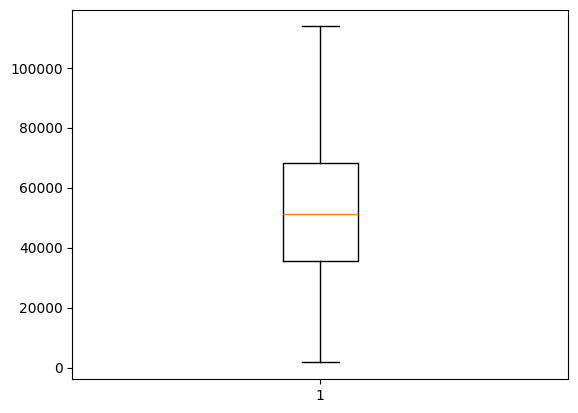

In [93]:
plt.boxplot(df['Income'])
plt.show()

In [94]:
print(df['Marital_Status'].unique())
print(df['Education'].unique())

['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']
['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']


In [ ]:
df['Marital_Status'] = np.where(
    df['Marital_Status'].isin(['Single', 'Alone', 'Absurd', 'YOLO']), 'Single',
    np.where(
        df['Marital_Status'].isin(['Married']), 'Married',
        np.where(
            df['Marital_Status']== 'Together', 'Together',
            np.where(
                df['Marital_Status'] == 'Widow', 'Widow',
                'Divorced'
            )
        )
    )
)
print(df['Marital_Status'].unique())

['Single' 'Together' 'Married' 'Divorced' 'Widow']


In [ ]:
df['Education'] = np.where(
    df['Education'] == 'PhD', 'Highly Qualified',
    np.where(
        df['Education'].isin(['Master', '2n Cycle', 'Graduation']), 'Medium Qualified',
        'Low Qualified'
    )
)
print(df['Education'].unique())

['Medium Qualified' 'Highly Qualified' 'Low Qualified']


In [ ]:
# Recency: days since last purchase
rfm_recency = df['Recency']

# Frequency: total number of purchases (sum of purchase columns)
rfm_frequency = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)

# Monetary: total amount spent (sum of monetary columns)
rfm_monetary = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

rfm = pd.DataFrame({
    'Recency': rfm_recency,
    'Frequency': rfm_frequency,
    'Monetary': rfm_monetary
})

# Assign (1-5) for each RFM dimension
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

# Combine RFM scores into a single RFM score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score'] = rfm['RFM_Score'].astype(int)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,58,22,1617,3,5,5,355
1,38,4,27,4,1,1,411
2,26,20,776,4,4,4,444
3,26,6,53,4,2,1,421
4,94,14,422,1,3,3,133


In [ ]:
df['R_Score'] = rfm['R_Score']
df['F_Score'] = rfm['F_Score']
df['M_Score'] = rfm['M_Score']
df['RFM_Score'] = rfm['RFM_Score']


df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,R_Score,F_Score,M_Score,RFM_Score
0,5524,1957,Medium Qualified,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,3,5,5,355
1,2174,1954,Medium Qualified,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,4,1,1,411
2,4141,1965,Medium Qualified,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,4,4,4,444
3,6182,1984,Medium Qualified,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,4,2,1,421
4,5324,1981,Highly Qualified,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,1,3,3,133


In [ ]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
print("Earliest date:", df['Dt_Customer'].min())
print("Latest date:", df['Dt_Customer'].max())

Earliest date: 2012-07-30 00:00:00
Latest date: 2014-06-29 00:00:00


In [ ]:
current_year = 2023
#Convert Year_Birth to integer
df['Year_Birth'] = df['Year_Birth'].astype(int)
df['Age'] = current_year - df['Year_Birth']
print(df[['Year_Birth', 'Age']].head())

   Year_Birth  Age
0        1957   66
1        1954   69
2        1965   58
3        1984   39
4        1981   42


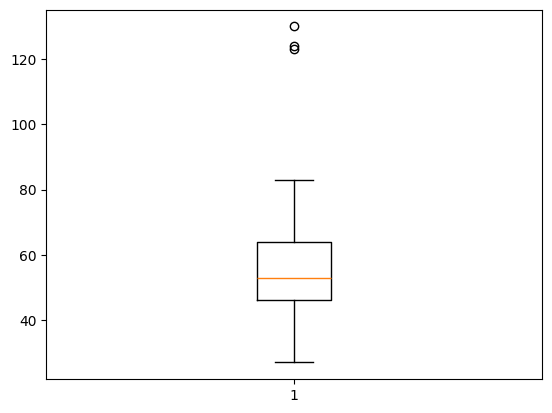

In [ ]:
plt.boxplot(df['Age'])
plt.show()

In [ ]:
age_bins = [0, 29, 39, 49, 59, 69, 79, np.inf]
age_labels = ['<30', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)
df[['Age', 'Age_Group']].head()

,Age,Age_Group
0,66,60-69
1,69,70-79
2,58,50-59
3,39,40-49
4,42,40-49


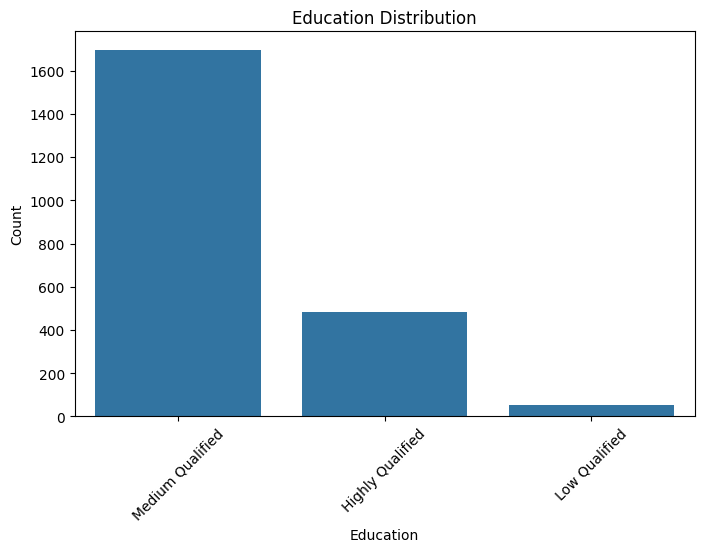

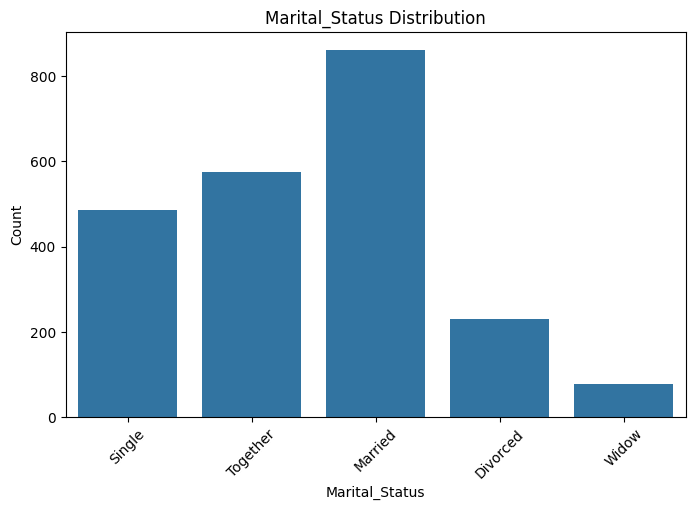

In [103]:
categorical_cols = ['Education', 'Marital_Status']
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, data=df)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

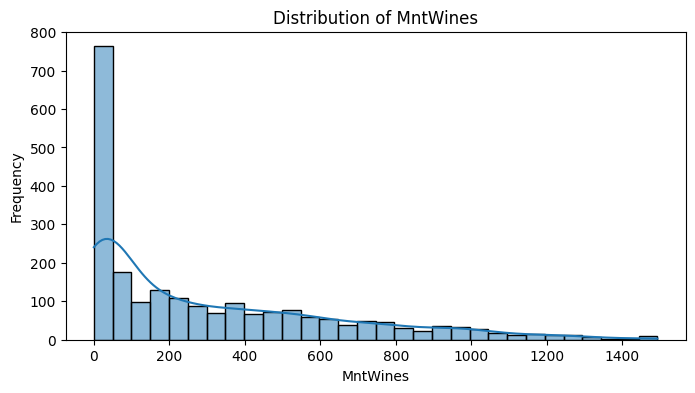

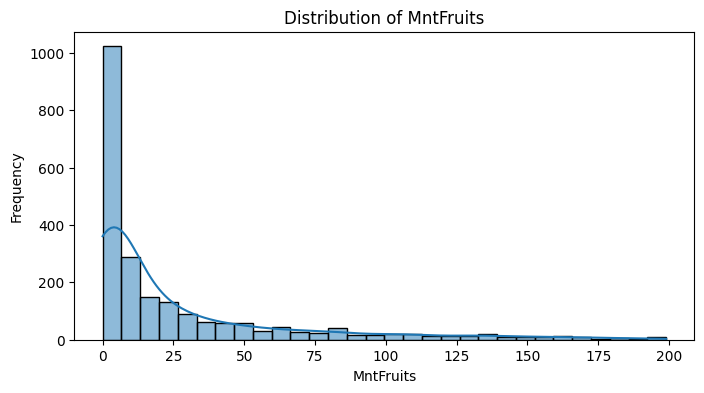

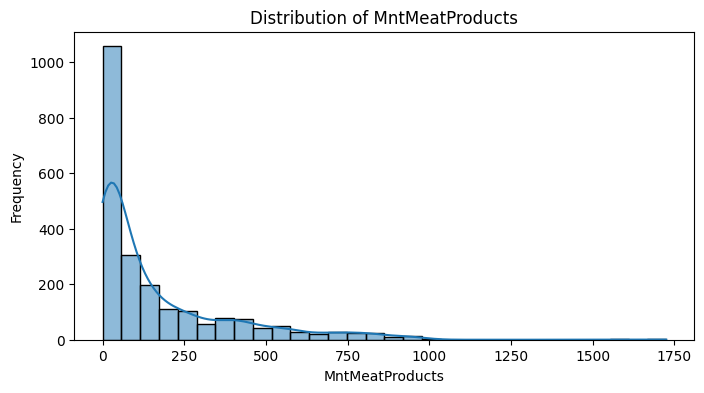

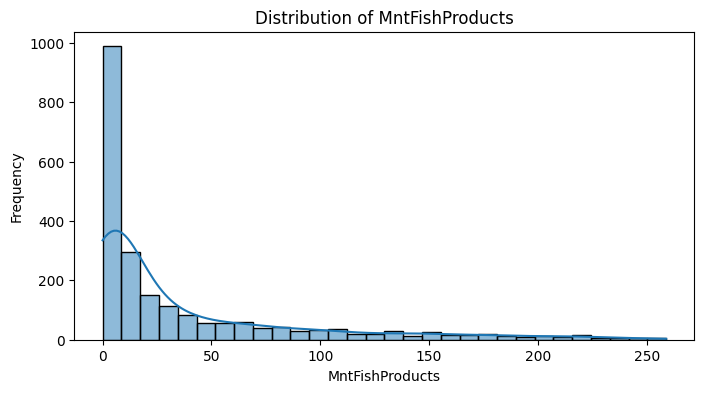

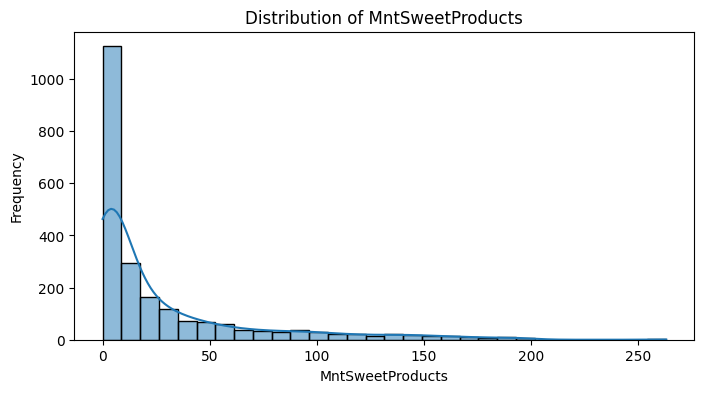

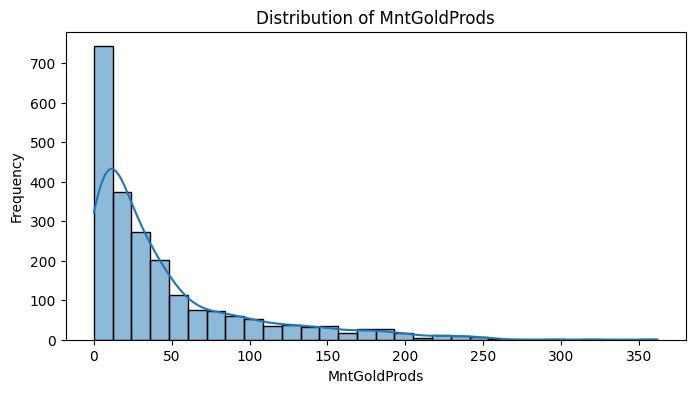

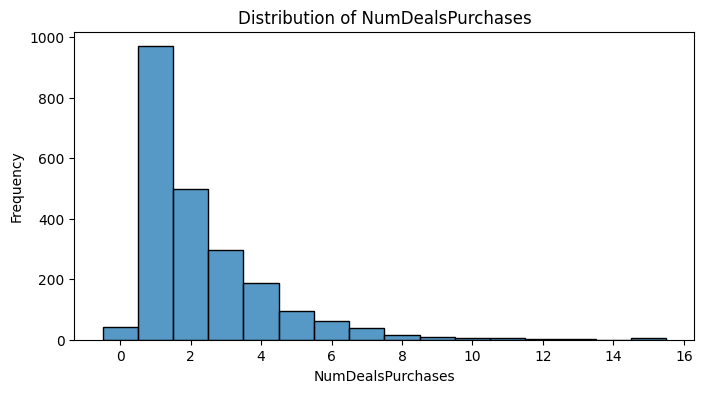

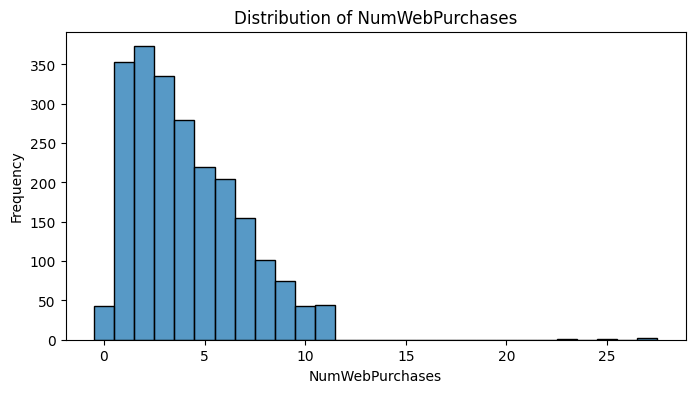

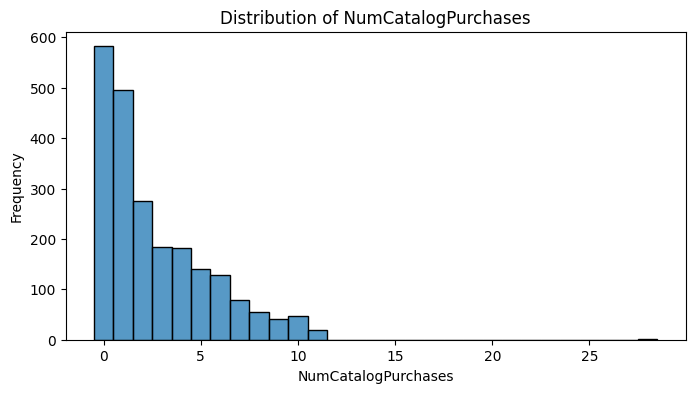

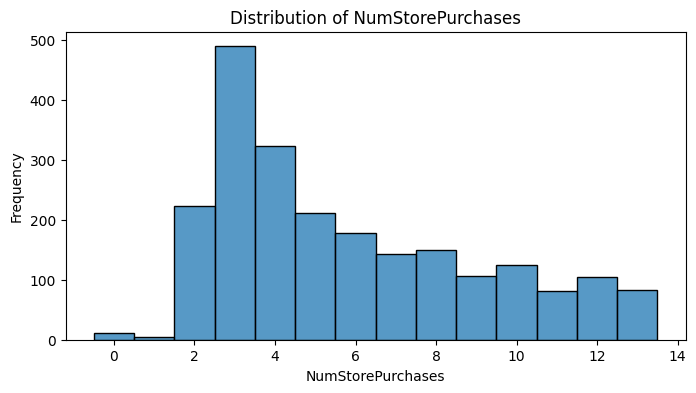

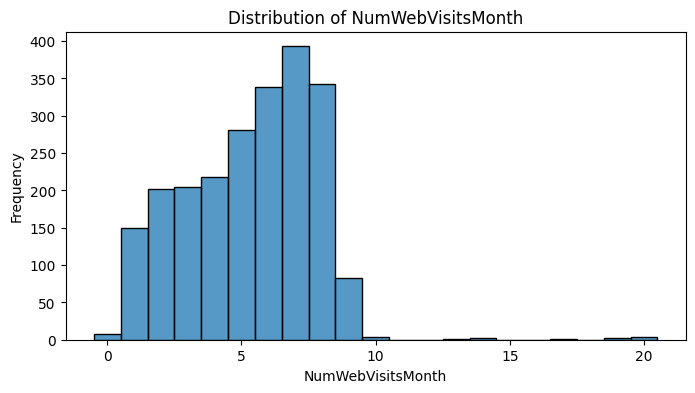

In [104]:
purchase_cols = [
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'NumWebVisitsMonth'
]

discrete_cols = [
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
    'NumStorePurchases', 'NumWebVisitsMonth'
]

for col in purchase_cols:
    plt.figure(figsize=(8, 4))
    if col in discrete_cols:
        sns.histplot(df[col], bins=range(df[col].min(), df[col].max()+2), discrete=True)
    else:
        sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [105]:
df['Z_CostContact'].unique(), df['Z_Revenue'].unique()

(array([3]), array([11]))

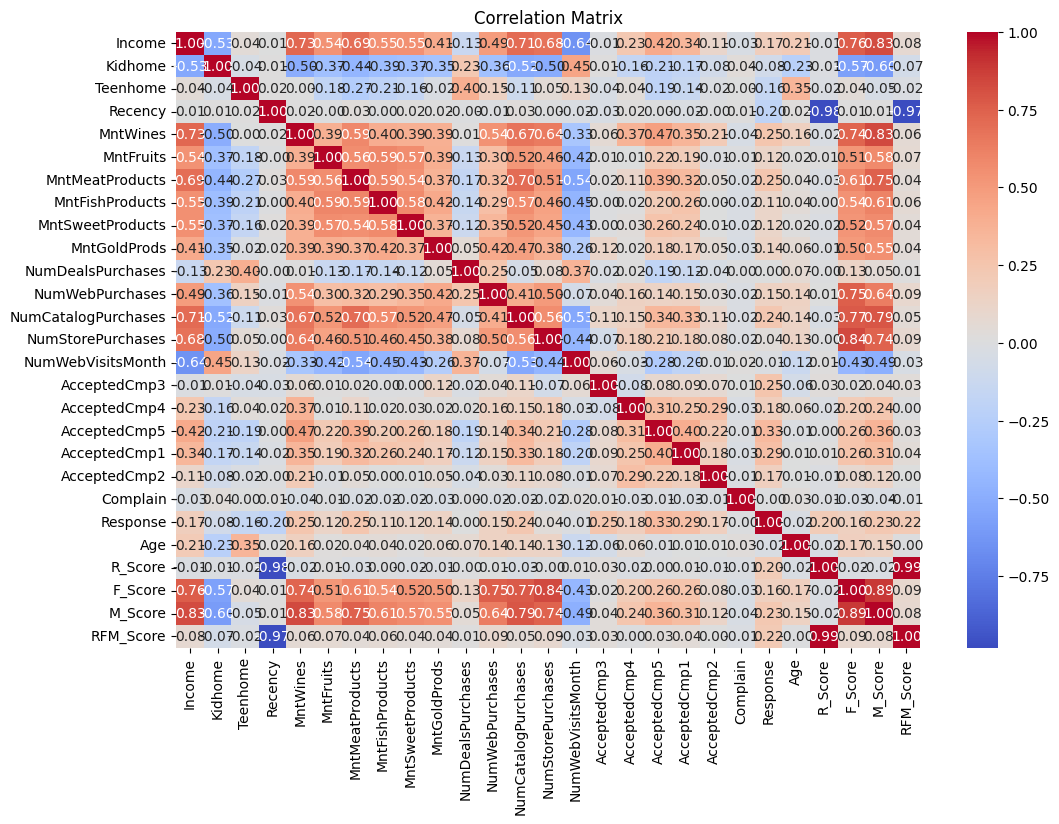

In [ ]:
corr_cols = ['Income', 'Kidhome',
    'Teenhome', 'Recency', 'MntWines', 'MntFruits',
    'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
    'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
    'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
    'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
    'AcceptedCmp2', 'Complain', 'Response',
    'Age', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score']

plt.figure(figsize=(12, 8))
corr = df[corr_cols].corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


In [107]:

# Cross-tabulation between 'Response' and 'Marital_Status'
ct_marital = pd.crosstab(df['Response'], df['Marital_Status'])
print("Cross-tabulation: Response vs Marital_Status")
print(ct_marital)

# Cross-tabulation between 'Response' and 'Education'
ct_education = pd.crosstab(df['Response'], df['Education'])
print("\nCross-tabulation: Response vs Education")
print(ct_education)

Cross-tabulation: Response vs Marital_Status
Marital_Status  Divorced  Married  Single  Together  Widow
Response                                                  
0                    183      763     378       516     58
1                     48       98     109        60     19

Cross-tabulation: Response vs Education
Education  Highly Qualified  Low Qualified  Medium Qualified
Response                                                    
0                       381             52              1465
1                       101              2               231


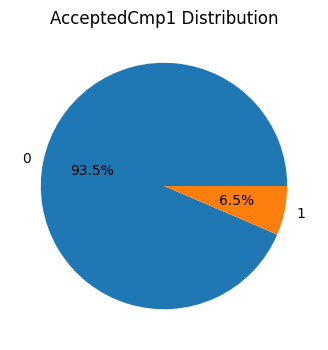

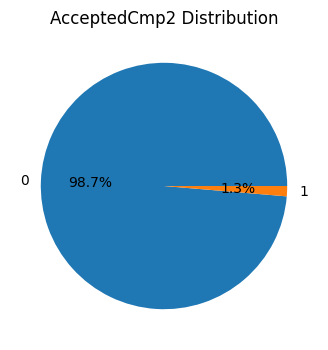

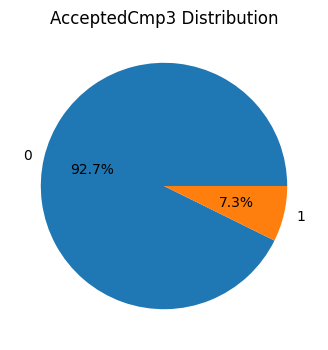

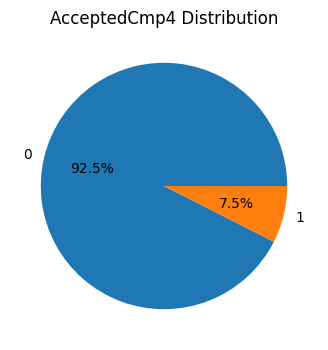

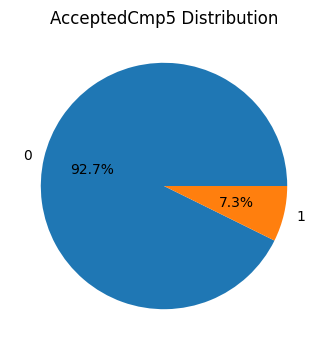

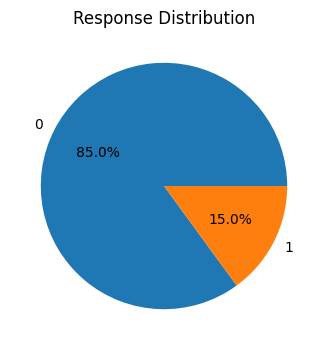

In [108]:
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                  'AcceptedCmp4', 'AcceptedCmp5', 'Response']
for col in campaign_cols:
    plt.figure(figsize=(6, 4))
    df[col].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title(f'{col} Distribution')
    plt.ylabel('')
    plt.show()

<Axes: xlabel='Age_Group', ylabel='count'>

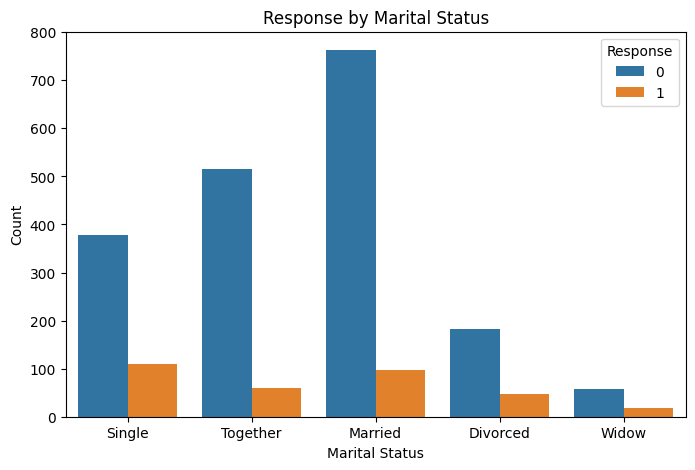

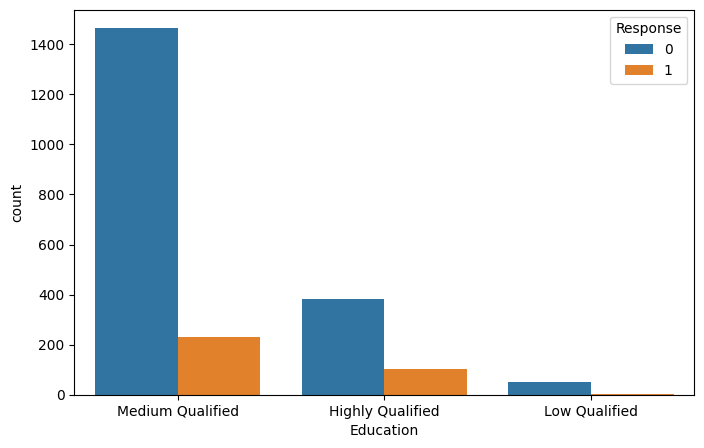

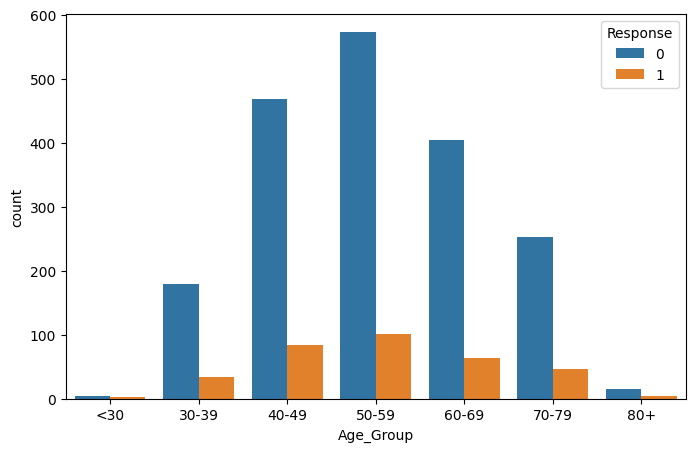

In [ ]:
# Response vs Marital Status
plt.figure(figsize=(8, 5))
sns.countplot(x='Marital_Status', hue='Response', data=df)
plt.title('Response by Marital Status')
plt.ylabel('Count')
plt.xlabel('Marital Status')
plt.title('Response by Marital Status')

# Response vs Education
plt.figure(figsize=(8, 5))
sns.countplot(x='Education', hue='Response', data=df)

# Response vs Age Groups
plt.figure(figsize=(8, 5))
sns.countplot(x='Age_Group', hue='Response', data=df)

In [ ]:
# Categorical and numerical columns
categorical_features = ['Education', 'Marital_Status', 'Age_Group']
numerical_features = [col for col in df.columns if df[col].dtype in [np.int64, np.float64] and col not in ['ID', 'Response', 'Z_CostContact', 'Z_Revenue', 'Year_Birth', 'Age']]

# One-hot encode categorical features
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_cats = encoder.fit_transform(df[categorical_features])
encoded_cat_df = pd.DataFrame(encoded_cats, columns=encoder.get_feature_names_out(categorical_features), index=df.index)

# Scale numerical features
scaler = StandardScaler()
scaled_nums = scaler.fit_transform(df[numerical_features])
scaled_num_df = pd.DataFrame(scaled_nums, columns=numerical_features, index=df.index)

# Combine encoded categorical and scaled numerical features
X_processed = pd.concat([scaled_num_df, encoded_cat_df], axis=1)
X_processed.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,R_Score,F_Score,M_Score,RFM_Score,Education_Low Qualified,Education_Medium Qualified,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Age_Group_40-49,Age_Group_50-59,Age_Group_60-69,Age_Group_70-79,Age_Group_80+,Age_Group_<30
0,0.315922,-0.825420,-0.931339,0.307081,0.980281,1.547741,1.735476,2.457243,1.472657,0.839843,0.359999,1.406699,2.634319,-0.557847,0.690949,-0.280681,-0.284379,-0.280681,-0.262613,-0.116722,-0.097458,-0.009805,1.41358,1.413899,0.144914,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.256684,1.031775,0.905012,-0.383851,-0.872949,-0.637496,-0.726318,-0.651911,-0.633057,-0.731254,-0.167937,-1.116638,-0.585333,-1.174850,-0.137299,-0.280681,-0.284379,-0.280681,-0.262613,-0.116722,-0.097458,0.696151,-1.41358,-1.411368,0.538607,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.970142,-0.825420,-0.931339,-0.798410,0.359568,0.568152,-0.174694,1.341605,-0.148984,-0.041504,-0.695872,1.406699,-0.227594,1.293165,-0.551424,-0.280681,-0.284379,-0.280681,-0.262613,-0.116722,-0.097458,0.696151,0.70679,0.707582,0.770605,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,-1.213033,1.031775,-0.931339,-0.798410,-0.872949,-0.562143,-0.662493,-0.505598,-0.584649,-0.750414,-0.167937,-0.756161,-0.943072,-0.557847,0.276825,-0.280681,-0.284379,-0.280681,-0.262613,-0.116722,-0.097458,0.696151,-0.70679,-1.411368,0.608909,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.323448,1.031775,-0.931339,1.550759,-0.391822,0.417446,-0.215724,0.152811,-0.003763,-0.558817,1.415871,0.325269,0.130145,0.059157,-0.137299,-0.280681,-0.284379,-0.280681,-0.262613,-0.116722,-0.097458,-1.421716,0.00000,0.001266,-1.415799,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Target variable
y = df['Response']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
print("Original training set shape:", y_train.value_counts().to_dict())

# Perform SMOTE on the training set only
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("Balanced training set shape:", y_train.value_counts().to_dict())

Original training set shape: {0: 1518, 1: 267}
Balanced training set shape: {0: 1518, 1: 1518}


  File "C:\Users\judec\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\judec\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1026, in __ini

In [ ]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
dtree = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)


# Define parameter grids for each model
param_grid_logreg = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear', 'saga'],
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'max_iter': [100, 500, 1000]
}

param_grid_dtree = {
    'max_depth': [3, 5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random']
}

param_grid_rf = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy', 'log_loss']
}

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Sanitize feature names for XGBoost (remove [, ], <, >, and spaces)
def sanitize_columns(df):
    df = df.copy()
    df.columns = (
        df.columns.str.replace('[\[\]<> ]', '_', regex=True)
        .str.replace('__+', '_', regex=True)
        .str.strip('_')
    )
    return df

X_train_xgb = sanitize_columns(X_train)
X_test_xgb = sanitize_columns(X_test)

# Logistic Regression Grid Search
gs_logreg = GridSearchCV(logreg, param_grid_logreg, cv=5, scoring='f1', n_jobs=-1)
gs_logreg.fit(X_train, y_train)
best_logreg = gs_logreg.best_estimator_

# Decision Tree Grid Search
gs_dtree = GridSearchCV(dtree, param_grid_dtree, cv=5, scoring='f1', n_jobs=-1)
gs_dtree.fit(X_train, y_train)
best_dtree = gs_dtree.best_estimator_

# Random Forest Grid Search
gs_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
gs_rf.fit(X_train, y_train)
best_rf = gs_rf.best_estimator_

# XGBoost Grid Search (use sanitized features)
gs_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='f1', n_jobs=-1)
gs_xgb.fit(X_train_xgb, y_train)
best_xgb = gs_xgb.best_estimator_

# Fit models with best parameters
best_logreg.fit(X_train, y_train)
best_dtree.fit(X_train, y_train)
best_rf.fit(X_train, y_train)
gb.fit(X_train, y_train)  # Gradient Boosting unchanged
best_xgb.fit(X_train_xgb, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [114]:
best_logreg

,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [115]:
best_dtree

,criterion,'gini'
,splitter,'random'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [116]:
best_rf


,n_estimators,100
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [117]:
gb

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [118]:
best_xgb

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [ ]:
# Predict on the test set
y_pred_logreg = best_logreg.predict(X_test)
y_pred_dtree = best_dtree.predict(X_test)
y_pred_rf = best_rf.predict(X_test)
y_pred_gb = gb.predict(X_test)
y_pred_xgb = best_xgb.predict(X_test_xgb)

# Collect metrics for each model
models = {
    "Logistic Regression": y_pred_logreg,
    "Decision Tree": y_pred_dtree,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb,
    "XGBoost": y_pred_xgb
}

for name, y_pred in models.items():
    print(f"\n{name}:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


Logistic Regression:
Accuracy: 0.8165548098434005
Precision: 0.4369747899159664
Recall: 0.7761194029850746
F1 Score: 0.5591397849462365
Confusion Matrix:
 [[313  67]
 [ 15  52]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.82      0.88       380
           1       0.44      0.78      0.56        67

    accuracy                           0.82       447
   macro avg       0.70      0.80      0.72       447
weighted avg       0.88      0.82      0.84       447


Decision Tree:
Accuracy: 0.8411633109619687
Precision: 0.4696969696969697
Recall: 0.4626865671641791
F1 Score: 0.46616541353383456
Confusion Matrix:
 [[345  35]
 [ 36  31]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91       380
           1       0.47      0.46      0.47        67

    accuracy                           0.84       447
   macro avg       0.69      0.69      0.69       447


In [ ]:
# Calculate ROC AUC for each model
for name, y_pred in models.items():
    # For ROC AUC, need predicted probabilities for the positive class
    if name == "Logistic Regression":
        y_proba = best_logreg.predict_proba(X_test)[:, 1]
    elif name == "Decision Tree":
        y_proba = best_dtree.predict_proba(X_test)[:, 1]
    elif name == "Random Forest":
        y_proba = best_rf.predict_proba(X_test)[:, 1]
    elif name == "Gradient Boosting":
        y_proba = gb.predict_proba(X_test)[:, 1]
    elif name == "XGBoost":
        y_proba = best_xgb.predict_proba(X_test_xgb)[:, 1]
    else:
        y_proba = None

    if y_proba is not None:
        auc = roc_auc_score(y_test, y_proba)
        print(f"{name} ROC AUC: {auc:.4f}")

Logistic Regression ROC AUC: 0.8869
Decision Tree ROC AUC: 0.6954
Random Forest ROC AUC: 0.8329
Gradient Boosting ROC AUC: 0.8958
XGBoost ROC AUC: 0.8850


<Figure size 700x500 with 0 Axes>

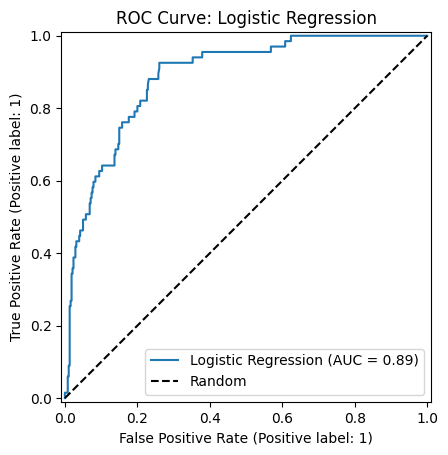

<Figure size 700x500 with 0 Axes>

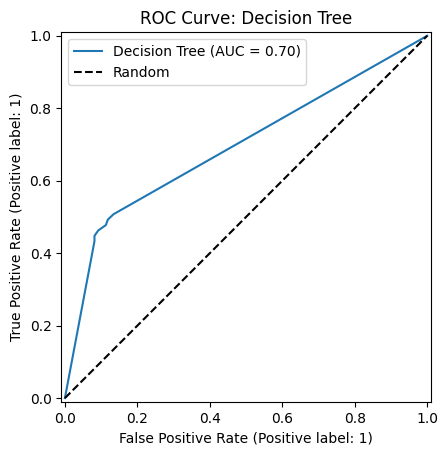

<Figure size 700x500 with 0 Axes>

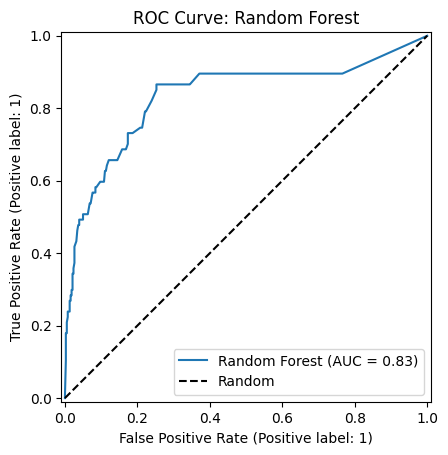

<Figure size 700x500 with 0 Axes>

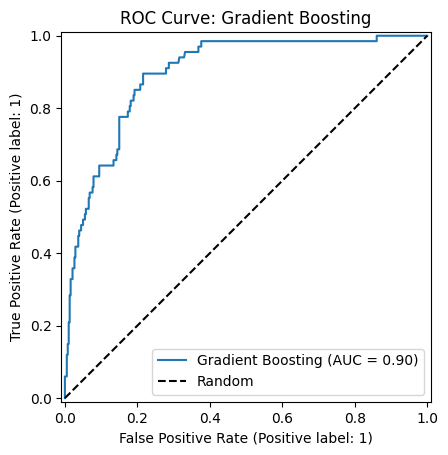

<Figure size 700x500 with 0 Axes>

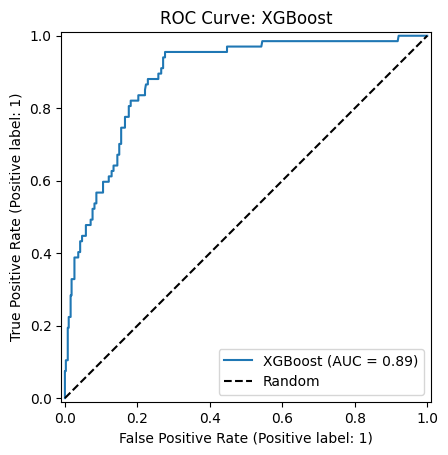

In [ ]:
# Plot ROC curve for each model separately
plt.figure(figsize=(7, 5))
RocCurveDisplay.from_estimator(best_logreg, X_test, y_test, name="Logistic Regression")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.title('ROC Curve: Logistic Regression')
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
RocCurveDisplay.from_estimator(best_dtree, X_test, y_test, name="Decision Tree")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.title('ROC Curve: Decision Tree')
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
RocCurveDisplay.from_estimator(best_rf, X_test, y_test, name="Random Forest")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.title('ROC Curve: Random Forest')
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
RocCurveDisplay.from_estimator(gb, X_test, y_test, name="Gradient Boosting")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.title('ROC Curve: Gradient Boosting')
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
RocCurveDisplay.from_estimator(best_xgb, X_test_xgb, y_test, name="XGBoost")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.title('ROC Curve: XGBoost')
plt.legend()
plt.show()


<Figure size 400x400 with 0 Axes>

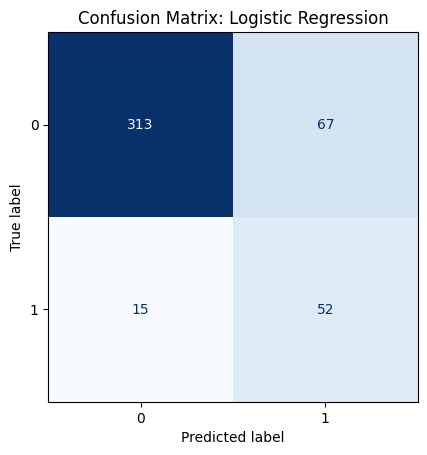

<Figure size 400x400 with 0 Axes>

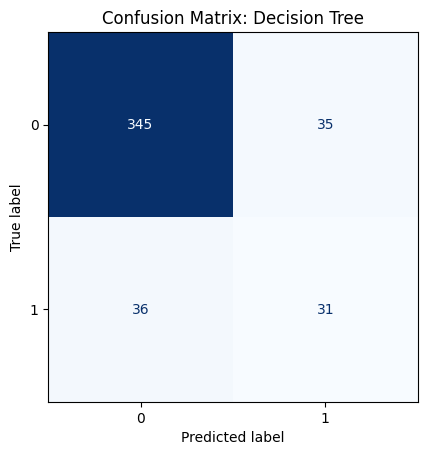

<Figure size 400x400 with 0 Axes>

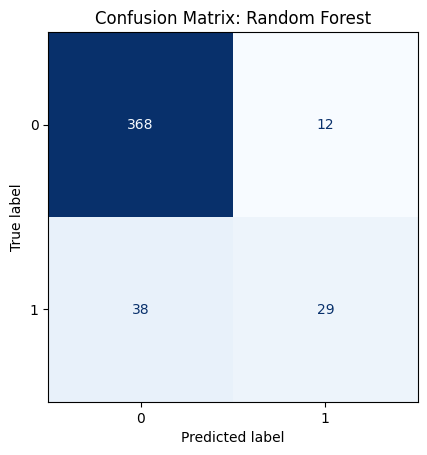

<Figure size 400x400 with 0 Axes>

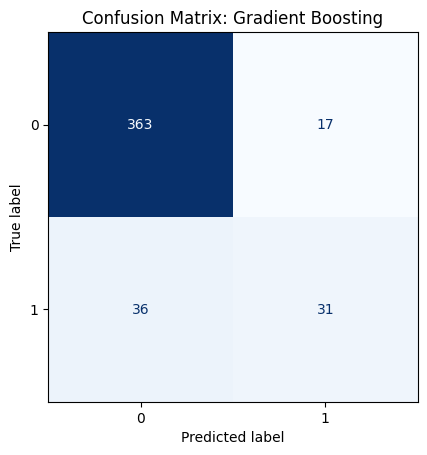

<Figure size 400x400 with 0 Axes>

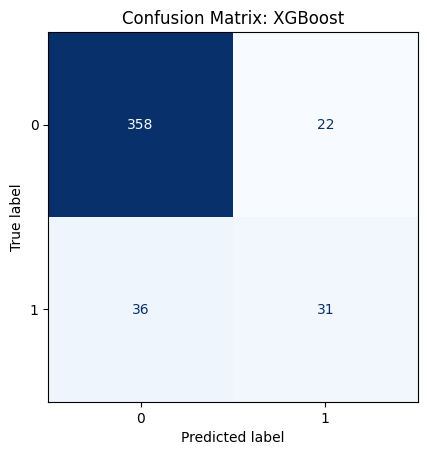

In [ ]:
model_preds = {
    "Logistic Regression": y_pred_logreg,
    "Decision Tree": y_pred_dtree,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb,
    "XGBoost": y_pred_xgb
}

for name, y_pred in model_preds.items():
    plt.figure(figsize=(4, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', colorbar=False)
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

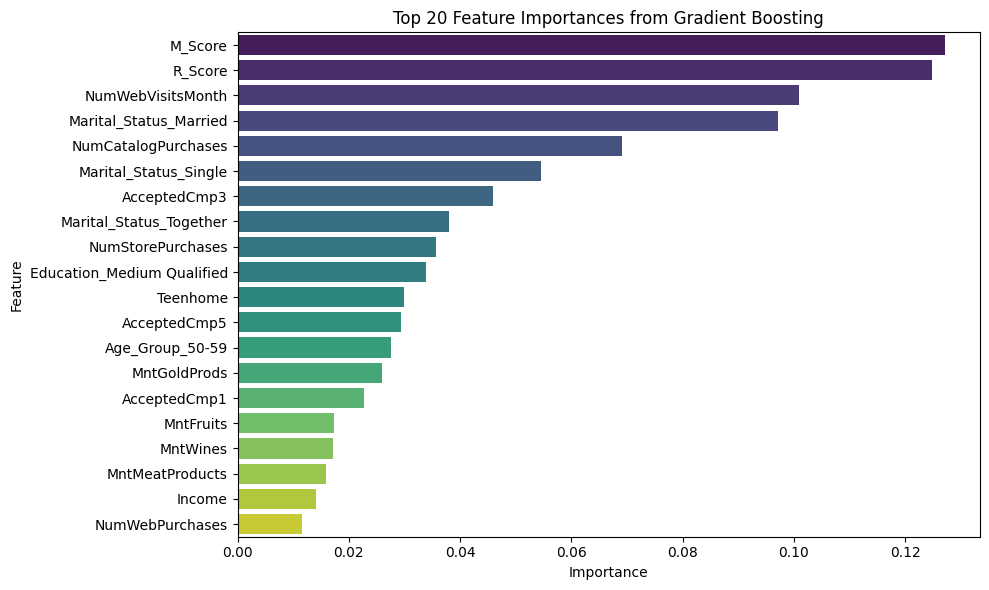

In [123]:
# Feature importance plot using Gradient Boosting
importances = gb.feature_importances_
feature_names = X_processed.columns

# Sort features by importance
indices = np.argsort(importances)[::-1]
# Show top 20 features
top_n = 20  

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices][:top_n], y=feature_names[indices][:top_n], palette="viridis")
plt.title("Top 20 Feature Importances from Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [124]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Age', 'Age_Group'],
      dtype='object')

Adoption Likelihood



In [ ]:
importances = gb.feature_importances_
feature_importance = pd.Series(importances, index=X_processed.columns).sort_values(ascending=False)
print("Top features influencing adoption likelihood (Gradient Boosting Classifier importances):")
print(feature_importance.head(25))

# Predict adoption likelihood for each customer using Gradient Boosting 
adoption_likelihood = gb.predict_proba(X_processed)[:, 1]
df['Adoption_Likelihood'] = adoption_likelihood


Top features influencing adoption likelihood (Gradient Boosting Classifier importances):
M_Score                       0.127101
R_Score                       0.124886
NumWebVisitsMonth             0.100964
Marital_Status_Married        0.097076
NumCatalogPurchases           0.069121
Marital_Status_Single         0.054563
AcceptedCmp3                  0.045964
Marital_Status_Together       0.037948
NumStorePurchases             0.035603
Education_Medium Qualified    0.033790
Teenhome                      0.029991
AcceptedCmp5                  0.029366
Age_Group_50-59               0.027532
MntGoldProds                  0.026027
AcceptedCmp1                  0.022699
MntFruits                     0.017365
MntWines                      0.017166
MntMeatProducts               0.015927
Income                        0.014012
NumWebPurchases               0.011568
NumDealsPurchases             0.010821
RFM_Score                     0.009341
Recency                       0.008223
AcceptedCmp4  

In [126]:
# Show customers with highest likelihood of adoption
print("\nTop 10 customers most likely to adopt:")
df[['ID', 'Age_Group', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'M_Score', 'R_Score', 'RFM_Score', 'NumWebVisitsMonth',
       'Adoption_Likelihood']].sort_values('Adoption_Likelihood', ascending=False).head(10)


Top 10 customers most likely to adopt:


,ID,Age_Group,Education,Marital_Status,Income,Kidhome,Teenhome,M_Score,R_Score,RFM_Score,NumWebVisitsMonth,Adoption_Likelihood
816,9493,40-49,Highly Qualified,Single,76412.0,0,0,5,5,545,3,0.962547
1716,569,30-39,Medium Qualified,Single,90273.0,0,0,5,4,445,2,0.960415
585,9058,60-69,Medium Qualified,Widow,79800.0,0,0,5,2,255,3,0.955863
1839,7872,40-49,Highly Qualified,Married,86836.0,0,0,3,5,553,5,0.950926
1523,830,30-39,Highly Qualified,Single,74004.0,0,0,5,5,535,3,0.946006
1955,3009,60-69,Highly Qualified,Widow,71670.0,0,0,5,5,535,6,0.945013
1751,3524,50-59,Medium Qualified,Single,39763.0,1,0,2,5,522,9,0.942401
876,8443,50-59,Medium Qualified,Single,24762.0,1,0,2,5,522,8,0.940567
1453,10133,50-59,Medium Qualified,Single,93790.0,0,0,5,5,555,2,0.939557
604,7141,30-39,Medium Qualified,Single,21888.0,1,0,3,5,523,10,0.936964


In [127]:
# Show customers with lowest likelihood of adoption
print("\nTop 10 customers least likely to adopt:")
df[['ID', 'Age_Group', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'M_Score', 'R_Score', 'RFM_Score', 'NumWebVisitsMonth',
       'Adoption_Likelihood']].sort_values('Adoption_Likelihood', ascending=True).head(10)


Top 10 customers least likely to adopt:


,ID,Age_Group,Education,Marital_Status,Income,Kidhome,Teenhome,M_Score,R_Score,RFM_Score,NumWebVisitsMonth,Adoption_Likelihood
177,10492,60-69,Medium Qualified,Together,38285.0,2,1,1,1,111,2,0.003572
434,9347,60-69,Medium Qualified,Together,50943.0,0,1,1,3,311,5,0.004221
503,10160,60-69,Medium Qualified,Together,50943.0,0,1,1,3,311,5,0.004221
566,891,70-79,Medium Qualified,Together,29298.0,1,1,1,2,211,5,0.004639
314,231,60-69,Medium Qualified,Together,28839.0,1,1,1,1,111,5,0.004723
1638,3829,40-49,Low Qualified,Together,24594.0,1,0,1,1,111,5,0.005470
105,8373,40-49,Low Qualified,Together,24594.0,1,0,1,1,111,5,0.005470
1598,800,60-69,Medium Qualified,Together,44512.0,1,1,1,3,311,4,0.006004
317,113,70-79,Medium Qualified,Married,30833.0,1,1,1,4,411,5,0.006049
1019,4550,50-59,Medium Qualified,Together,33564.0,0,1,2,3,312,5,0.006079


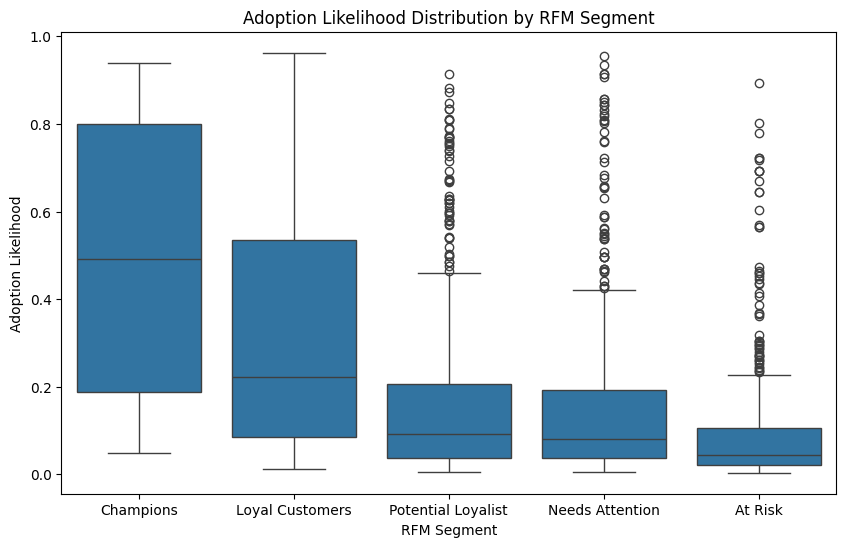

In [128]:
# Create RFM segments based on RFM_Score
def rfm_segment(score):
    if score >= 555:
        return 'Champions'
    elif score >= 444:
        return 'Loyal Customers'
    elif score >= 333:
        return 'Potential Loyalist'
    elif score >= 222:
        return 'Needs Attention'
    else:
        return 'At Risk'

df['RFM_Segment'] = df['RFM_Score'].apply(rfm_segment)

# Visualize the distribution of adoption likelihood for each segment
plt.figure(figsize=(10, 6))
sns.boxplot(x='RFM_Segment', y='Adoption_Likelihood', data=df, order=['Champions', 'Loyal Customers', 'Potential Loyalist', 'Needs Attention', 'At Risk'])
plt.title('Adoption Likelihood Distribution by RFM Segment')
plt.xlabel('RFM Segment')
plt.ylabel('Adoption Likelihood')
plt.show()

In [129]:
# Calculate mean predicted adoption likelihood for each RFM Segment
mean_adoption_by_segment = df.groupby('RFM_Segment')['Adoption_Likelihood'].mean().loc[
    ['Champions', 'Loyal Customers', 'Potential Loyalist', 'Needs Attention', 'At Risk']
]
mean_adoption_by_segment

RFM_Segment
Champions             0.498435
Loyal Customers       0.322598
Potential Loyalist    0.169517
Needs Attention       0.158675
At Risk               0.094365
Name: Adoption_Likelihood, dtype: float64

Number of users in each RFM segment:
RFM_Segment
Champions              29
Loyal Customers       575
Potential Loyalist    560
Needs Attention       531
At Risk               537
Name: count, dtype: int64


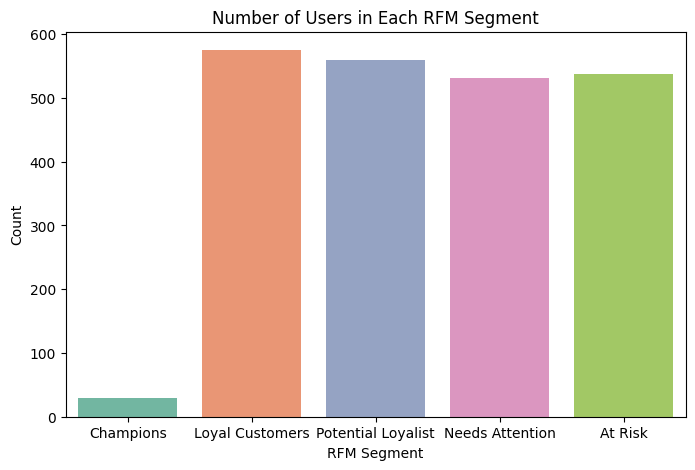

In [130]:
# Distribution of number of users in each RFM segment
rfm_segment_counts = df['RFM_Segment'].value_counts().loc[
    ['Champions', 'Loyal Customers', 'Potential Loyalist', 'Needs Attention', 'At Risk']
]
print("Number of users in each RFM segment:")
print(rfm_segment_counts)

# Optional: plot the distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=rfm_segment_counts.index, y=rfm_segment_counts.values, palette="Set2")
plt.title("Number of Users in Each RFM Segment")
plt.xlabel("RFM Segment")
plt.ylabel("Count")
plt.show()

In [131]:
# Create income range bins and labels
income_bins = [0, 20000, 40000, 60000, 80000, 100000, np.inf]
income_labels = ['<20k', '20-40k', '40-60k', '60-80k', '80-100k', '100k+']
df['Income_Range'] = pd.cut(df['Income'], bins=income_bins, labels=income_labels, right=False)
df[['Income', 'Income_Range']].head()

,Income,Income_Range
0,58138.0,40-60k
1,46344.0,40-60k
2,71613.0,60-80k
3,26646.0,20-40k
4,58293.0,40-60k


In [132]:
# Define a threshold for high adoption likelihood (e.g., top 20%)
threshold = df['Adoption_Likelihood'].quantile(0.8)

# Filter customers with high adoption likelihood
target_customers = df[df['Adoption_Likelihood'] >= threshold]

# Analyze the most common profiles among these customers
profile_summary = target_customers.groupby(['Education', 'Marital_Status', 'RFM_Segment'])['ID'].count().reset_index()
profile_summary = profile_summary.rename(columns={'ID': 'Count'}).sort_values('Count', ascending=False).reset_index(drop=True)

print("Top customer profiles to target based on high adoption likelihood:")
profile_summary.head(20)

Top customer profiles to target based on high adoption likelihood:


,Education,Marital_Status,RFM_Segment,Count
0,Medium Qualified,Single,Loyal Customers,53
1,Medium Qualified,Married,Loyal Customers,52
2,Medium Qualified,Together,Loyal Customers,36
3,Medium Qualified,Single,Potential Loyalist,34
4,Highly Qualified,Single,Loyal Customers,24
5,Highly Qualified,Married,Loyal Customers,20
6,Medium Qualified,Divorced,Loyal Customers,20
7,Medium Qualified,Single,Needs Attention,16
8,Medium Qualified,Married,Needs Attention,12
9,Medium Qualified,Together,Needs Attention,12


In [133]:
# Find customer profiles with lowest adoption likelihood (bottom 20%)
low_threshold = df['Adoption_Likelihood'].quantile(0.2)
low_adoption_customers = df[df['Adoption_Likelihood'] <= low_threshold]

# Analyze the most common profiles among these low-likelihood customers
low_profile_summary = low_adoption_customers.groupby(
    [ 'Education', 'Marital_Status', 'RFM_Segment']
)['ID'].count().reset_index()
low_profile_summary = low_profile_summary.rename(columns={'ID': 'Count'}).sort_values('Count', ascending=False).reset_index(drop=True)

print("Top customer profiles to target based on low adoption likelihood:")
low_profile_summary.head(20)

Top customer profiles to target based on low adoption likelihood:


,Education,Marital_Status,RFM_Segment,Count
0,Medium Qualified,Married,At Risk,74
1,Medium Qualified,Together,At Risk,59
2,Medium Qualified,Married,Potential Loyalist,50
3,Medium Qualified,Married,Needs Attention,34
4,Medium Qualified,Together,Potential Loyalist,31
5,Medium Qualified,Together,Needs Attention,28
6,Medium Qualified,Married,Loyal Customers,17
7,Medium Qualified,Single,At Risk,14
8,Highly Qualified,Married,Needs Attention,13
9,Medium Qualified,Together,Loyal Customers,12
